In [ ]:
# Anomaly Detection in Aircraft Maintenance Logs
# ---------------------------------------------------------------
# Step 1: Setup my environment and import libraries

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve, average_precision_score

# For visualization (optional)
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

np.random.seed(42)
OUT_DIR = "dissertation_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
print("Setup complete. Outputs will be stored in:", OUT_DIR)

Setup complete. Outputs will be stored in: dissertation_outputs


In [ ]:
# Step 2: Helper functions for plotting and metrics

from IPython.display import display, Image

def save_and_show(path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    display(plt.gcf())
    plt.close()

def pr_plot(y_true, scores, title, out_png, color):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label=f'AP={ap:.3f}', color=color, linewidth=2)
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(title)
    plt.legend(loc="best")
    save_and_show(out_png)
    return float(ap)

def precision_at_k(y_true, score, k=100):
    idx = np.argsort(-score)[:k]
    return float(np.mean(y_true[idx]))

In [ ]:
# Step 3: Upload and load my maintenance logs and lexicons

try:
    from google.colab import files
    uploaded = files.upload()
    print("Uploaded files:", list(uploaded.keys()))
except (ImportError, ModuleNotFoundError):
    print("Not running in Google Colab -- assuming CSV files are already in the current directory.")

FILE_LOGS  = "Aircraft_Annotation_DataFile.csv"
FILE_ABBR  = "Aviation_Abbreviation_Dataset.csv"
FILE_GRAM  = "Aviation_grammar_Dataset.csv"
FILE_MORPH = "Aviation_Morphosyntactic_Dataset.csv"
FILE_TERM  = "Aviation_TermBanks_Dataset.csv"

logs  = pd.read_csv(FILE_LOGS)
abbr  = pd.read_csv(FILE_ABBR)
gram  = pd.read_csv(FILE_GRAM)
morph = pd.read_csv(FILE_MORPH)
term  = pd.read_csv(FILE_TERM)

# Quick checks
assert {"PROBLEM","ACTION"}.issubset(logs.columns)
if "IDENT" not in logs.columns:
    logs["IDENT"] = np.arange(1, len(logs)+1)
print("Data loaded. Logs shape:", logs.shape)
display(logs.head(3))

KeyboardInterrupt: 

In [ ]:
# Step 4: Build lexicon dictionaries for normalization

abbr = abbr.rename(columns={c: c.lower() for c in abbr.columns})
abbr_map = dict(zip(
    abbr["abbreviated"].astype(str).str.lower(),
    abbr["standard_description"].astype(str).str.lower()
))

def s_lower(x): return str(x).lower() if pd.notnull(x) else ""
lemma_map = {}
for df in (gram, morph):
    for _, row in df.iterrows():
        word = s_lower(row.get("Word", row.get("word", "")))
        lemma = s_lower(row.get("Lemma", row.get("lemma", word)))
        if word: lemma_map[word] = lemma if lemma else word

term_words = set(term["Word"].astype(str).str.lower())
print(f"Abbreviations: {len(abbr_map)}, Lemmas: {len(lemma_map)}, Terms: {len(term_words)}")

Abbreviations: 64, Lemmas: 58, Terms: 96


In [ ]:
# Step 5: Tokenize and normalize each log entry

token_re = re.compile(r"[A-Za-z0-9/#\-']+")

def tokenize(text):
    return token_re.findall(str(text).lower())

def expand_abbreviations(tokens):
    out = []
    for t in tokens:
        if t in abbr_map:
            out.extend(abbr_map[t].split())
            out.append(t)
        else:
            out.append(t)
    return out

def lemmatize(tokens):
    return [lemma_map.get(t, t) for t in tokens]

def normalize(text):
    toks = tokenize(text)
    toks = expand_abbreviations(toks)
    toks = lemmatize(toks)
    return toks

logs["text_notes"] = (logs["PROBLEM"].astype(str) + " " + logs["ACTION"].astype(str)).str.strip()
logs["tokens"] = logs["text_notes"].apply(normalize)
display(logs[["IDENT","text_notes","tokens"]].head(3))

,IDENT,text_notes,tokens
0,100001,ENGINE IDLE OVERRIDE KILLED ENGINE. TRIED TO A...,"[engine, idle, override, killed, engine, tried..."
1,100002,ENGINE IDLE OVERRIDE KILLED ENGINE. REMOVED & ...,"[engine, idle, override, killed, engine, remov..."
2,100003,ENGINE IDLE OVERRIDE KILLED ENGINE. A/C WAS RU...,"[engine, idle, override, killed, engine, a/c, ..."


In [ ]:
# Step 6: Basic feature engineering

NEG = {"no","not","without","never","none"}
logs["text_len"] = logs["tokens"].apply(len)
logs["abbr_hits"] = logs["text_notes"].apply(lambda s: sum(1 for t in tokenize(s) if t in abbr_map))
logs["termbank_hits"] = logs["tokens"].apply(lambda toks: sum(1 for t in toks if t in term_words))
logs["neg_hits"] = logs["tokens"].apply(lambda toks: sum(1 for t in toks if t in NEG))
display(logs[["IDENT","text_len","abbr_hits","termbank_hits","neg_hits"]].head())

,IDENT,text_len,abbr_hits,termbank_hits,neg_hits
0,100001,13,0,2,0
1,100002,9,0,2,0
2,100003,17,0,2,2
3,100004,21,1,3,0
4,100005,12,1,1,0


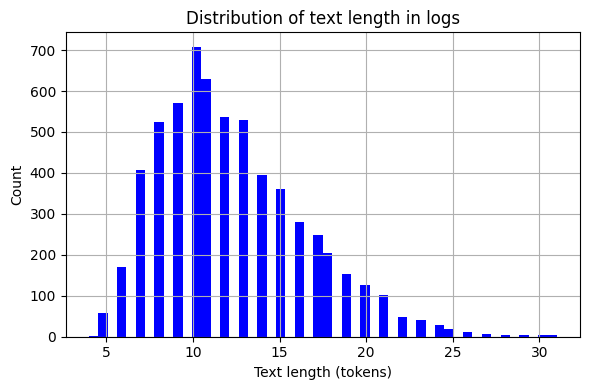

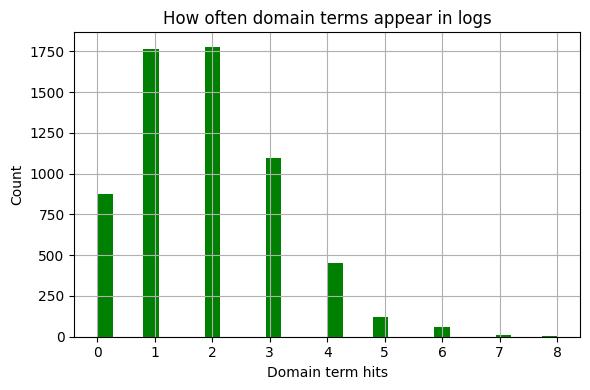

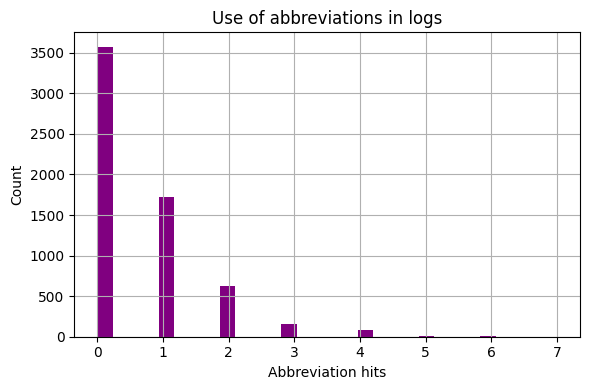

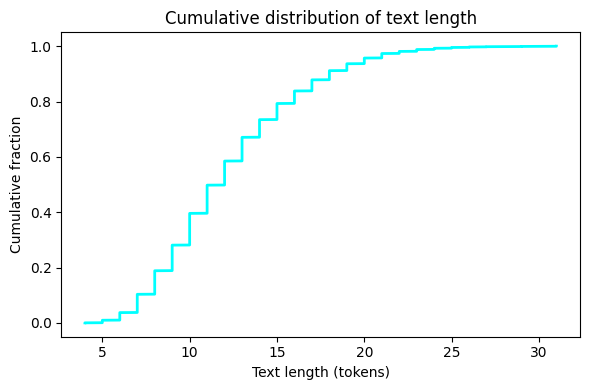

EDA complete — distributions saved.


In [ ]:
# Step 7: Quick exploratory data analysis

plt.figure(figsize=(6,4))
logs["text_len"].hist(bins=50, color="blue")
plt.xlabel("Text length (tokens)"); plt.ylabel("Count")
plt.title("Distribution of text length in logs")
save_and_show(f"{OUT_DIR}/text_len_hist.png")

plt.figure(figsize=(6,4))
logs["termbank_hits"].hist(bins=30, color="green")
plt.xlabel("Domain term hits"); plt.ylabel("Count")
plt.title("How often domain terms appear in logs")
save_and_show(f"{OUT_DIR}/termbank_hist.png")

plt.figure(figsize=(6,4))
logs["abbr_hits"].hist(bins=30, color="purple")
plt.xlabel("Abbreviation hits"); plt.ylabel("Count")
plt.title("Use of abbreviations in logs")
save_and_show(f"{OUT_DIR}/abbr_hist.png")

x = np.sort(logs["text_len"].values)
y = np.arange(1, len(x)+1)/len(x)
plt.figure(figsize=(6,4))
plt.plot(x, y, color="cyan", linewidth=2)
plt.xlabel("Text length (tokens)"); plt.ylabel("Cumulative fraction")
plt.title("Cumulative distribution of text length")
save_and_show(f"{OUT_DIR}/text_len_cdf.png")

print("EDA complete — distributions saved.")

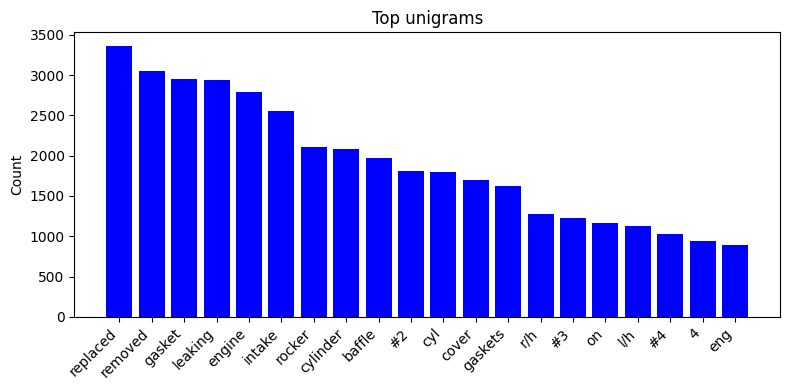

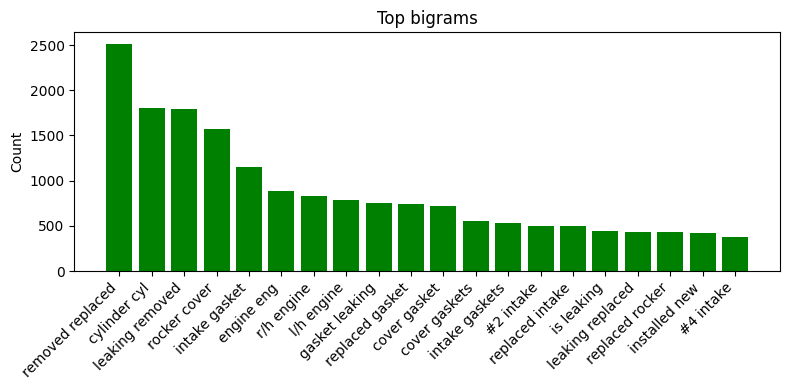

Token frequency plots generated.


In [ ]:
# Step 8: Most frequent unigrams/bigrams

from collections import Counter
unigrams, bigrams = Counter(), Counter()
for toks in logs["tokens"]:
    unigrams.update(toks)
    bigrams.update(zip(toks, toks[1:]))

def bar_top(counter, k, title, out_png, color):
    items = counter.most_common(k)
    if not items: return
    labels, vals = zip(*[(" ".join(x) if isinstance(x, tuple) else x, v) for x,v in items])
    plt.figure(figsize=(8,4))
    plt.bar(range(len(vals)), vals, color=color)
    plt.xticks(range(len(vals)), labels, rotation=45, ha="right")
    plt.ylabel("Count"); plt.title(title)
    save_and_show(out_png)

bar_top(unigrams, 20, "Top unigrams", f"{OUT_DIR}/top_unigrams.png", "blue")
bar_top(bigrams, 20, "Top bigrams",  f"{OUT_DIR}/top_bigrams.png",  "green")
print("Token frequency plots generated.")

In [ ]:
# Step 9: Feature extraction for ML models

logs["norm_text"] = logs["tokens"].apply(lambda toks: " ".join(toks))
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=3, token_pattern=r"(?u)\b\w+\b")
X_text_all = tfidf.fit_transform(logs["norm_text"])
X_struct_raw = logs[["text_len","termbank_hits","abbr_hits","neg_hits"]].astype(float).fillna(0.0).values
scaler = StandardScaler(with_mean=False)
X_struct_all = scaler.fit_transform(X_struct_raw)
print("Feature extraction complete.")
print("TF-IDF shape:", X_text_all.shape, "| Structured shape:", X_struct_all.shape)

Feature extraction complete.
TF-IDF shape: (6169, 3827) | Structured shape: (6169, 4)


In [ ]:
# Step 10: Generate transformer (BERT) embeddings for each log

from transformers import AutoTokenizer, AutoModel
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased").to(device)

def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**{k: v.to(device) for k, v in inputs.items()})
    return outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

print("Generating BERT embeddings for all notes (this may take time)...")
logs["bert_emb"] = logs["text_notes"].apply(get_embedding)
bert_matrix = np.stack(logs["bert_emb"].values)
print("Shape of BERT embedding matrix:", bert_matrix.shape)

Generating BERT embeddings for all notes (this may take time)...
Shape of BERT embedding matrix: (6169, 768)


In [ ]:
# Step 11: Split into train and validation sets

idx = np.arange(len(logs))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42)
X_text_train, X_text_val = X_text_all[train_idx], X_text_all[val_idx]
X_struct_train, X_struct_val = X_struct_all[train_idx], X_struct_all[val_idx]
bert_train, bert_val = bert_matrix[train_idx], bert_matrix[val_idx]
val_df = logs.iloc[val_idx].reset_index(drop=True)
print(f"Training samples: {len(train_idx)}, Validation samples: {len(val_idx)}")

Training samples: 4935, Validation samples: 1234


In [ ]:
# Step 12: Train classical ML anomaly detectors

ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm.fit(X_text_train)
text_scores = -ocsvm.decision_function(X_text_val)

iso = IsolationForest(n_estimators=400, contamination=0.02, random_state=42)
iso.fit(X_struct_train)
if_scores = -iso.score_samples(X_struct_val)

mm = MinMaxScaler()
hybrid_scores = mm.fit_transform(np.vstack([if_scores, text_scores]).T).mean(axis=1)
print("Classical models trained and scored.")

Classical models trained and scored.


Epoch 1/25 | Loss: 0.02731
Epoch 2/25 | Loss: 0.00944
Epoch 3/25 | Loss: 0.00807
Epoch 4/25 | Loss: 0.00721
Epoch 5/25 | Loss: 0.00685
Epoch 6/25 | Loss: 0.00673
Epoch 7/25 | Loss: 0.00667
Epoch 8/25 | Loss: 0.00662
Epoch 9/25 | Loss: 0.00656
Epoch 10/25 | Loss: 0.00650
Epoch 11/25 | Loss: 0.00645
Epoch 12/25 | Loss: 0.00640
Epoch 13/25 | Loss: 0.00636
Epoch 14/25 | Loss: 0.00633
Epoch 15/25 | Loss: 0.00630
Epoch 16/25 | Loss: 0.00628
Epoch 17/25 | Loss: 0.00626
Epoch 18/25 | Loss: 0.00624
Epoch 19/25 | Loss: 0.00622
Epoch 20/25 | Loss: 0.00620
Epoch 21/25 | Loss: 0.00618
Epoch 22/25 | Loss: 0.00614
Epoch 23/25 | Loss: 0.00613
Epoch 24/25 | Loss: 0.00611
Epoch 25/25 | Loss: 0.00608


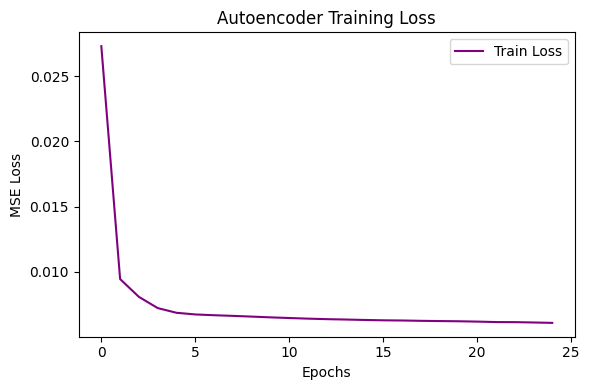

Autoencoder anomaly scores computed.


In [ ]:
# Step 13: Deep learning anomaly detection with autoencoder (BERT embeddings)

import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

def train_autoencoder(X, epochs=25, batch_size=32, lr=1e-3):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = Autoencoder(X.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch in loader:
            xb = batch[0].to(device)
            output = model(xb)
            loss = loss_fn(output, xb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * xb.size(0)
        avg_loss = epoch_loss/len(X)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.5f}")
    plt.figure(figsize=(6,4))
    plt.plot(losses, label="Train Loss", color="purple")
    plt.xlabel("Epochs"); plt.ylabel("MSE Loss")
    plt.title("Autoencoder Training Loss")
    plt.legend()
    save_and_show(f"{OUT_DIR}/autoencoder_loss.png")
    return model

autoencoder = train_autoencoder(bert_train, epochs=25, batch_size=32, lr=1e-3)

def get_recon_error(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        output = model(X_tensor).cpu().numpy()
        errors = np.mean((output - X)**2, axis=1)
    return errors

deep_scores = get_recon_error(autoencoder, bert_val)
print("Autoencoder anomaly scores computed.")

In [ ]:
# Step 14: Create proxy anomaly labels (rarity + effort)

from collections import Counter
df_counts = Counter()
for toks in logs["tokens"]:
    df_counts.update(set(toks))

freqs = np.array(list(df_counts.values()))
rare_cut = np.quantile(freqs, 0.05)
rare_tokens = {tok for tok, c in df_counts.items() if c <= rare_cut}

def rare_ratio(tokens):
    n = len(tokens)
    return 0 if n==0 else sum(1 for t in tokens if t in rare_tokens)/n

logs["rare_ratio"] = logs["tokens"].apply(rare_ratio)
logs["action_len_tokens"] = logs["ACTION"].astype(str).apply(lambda s: len(s.split()))
rare_thresh   = logs["rare_ratio"].quantile(0.95)
effort_thresh = logs["action_len_tokens"].quantile(0.90)
proxy_rare   = (logs["rare_ratio"] >= rare_thresh).astype(int)
proxy_effort = (logs["action_len_tokens"] >= effort_thresh).astype(int)
proxy_all    = np.clip(proxy_rare + proxy_effort, 0, 1)
y_val   = proxy_all.iloc[val_idx].values
print("Proxy labels generated (rarity + effort).")
print(f"Proxy anomaly rate in validation set: {y_val.mean():.3f}")

Proxy labels generated (rarity + effort).
Proxy anomaly rate in validation set: 0.206


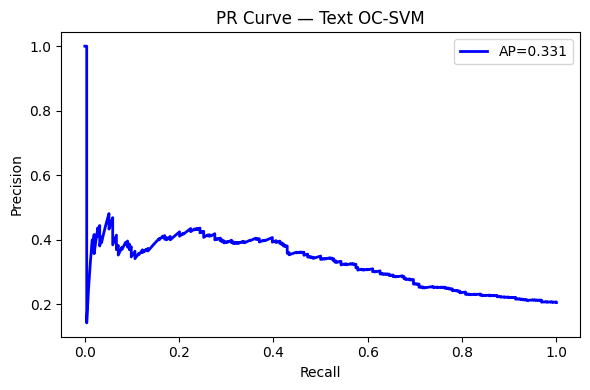

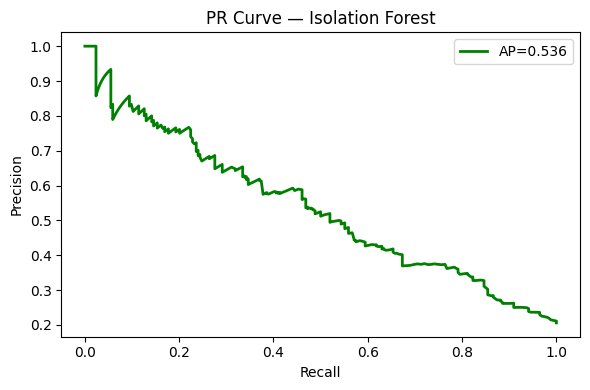

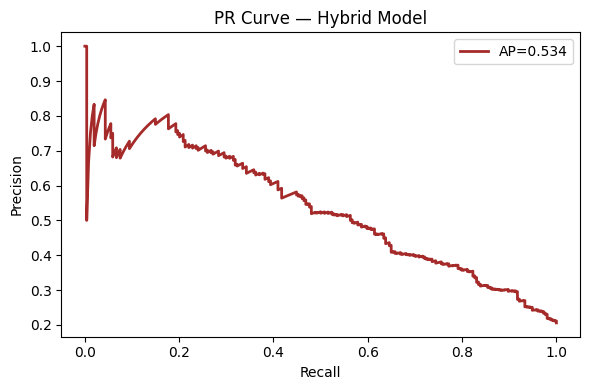

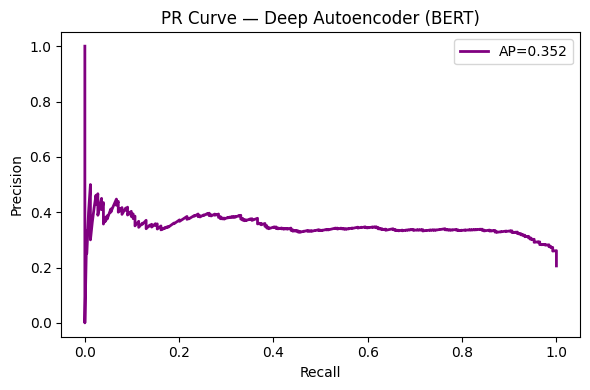

Evaluation complete. Results saved as JSON and figures.


,AP,P@50,P@100
Text_OCSVM,0.331060,0.36,0.40
IsolationForest,0.535862,0.78,0.68
Hybrid,0.534074,0.78,0.69
DeepAutoencoder,0.351932,0.40,0.35


In [ ]:
# Step 15: Evaluate all models (classical and deep)

results = {
    "Text_OCSVM": {
        "AP": pr_plot(y_val, text_scores, "PR Curve — Text OC-SVM", f"{OUT_DIR}/pr_text.png", "blue"),
        "P@50": precision_at_k(y_val, text_scores, 50),
        "P@100": precision_at_k(y_val, text_scores, 100)
    },
    "IsolationForest": {
        "AP": pr_plot(y_val, if_scores, "PR Curve — Isolation Forest", f"{OUT_DIR}/pr_if.png", "green"),
        "P@50": precision_at_k(y_val, if_scores, 50),
        "P@100": precision_at_k(y_val, if_scores, 100)
    },
    "Hybrid": {
        "AP": pr_plot(y_val, hybrid_scores, "PR Curve — Hybrid Model", f"{OUT_DIR}/pr_hybrid.png", "brown"),
        "P@50": precision_at_k(y_val, hybrid_scores, 50),
        "P@100": precision_at_k(y_val, hybrid_scores, 100)
    },
    "DeepAutoencoder": {
        "AP": pr_plot(y_val, deep_scores, "PR Curve — Deep Autoencoder (BERT)", f"{OUT_DIR}/pr_deep.png", "purple"),
        "P@50": precision_at_k(y_val, deep_scores, 50),
        "P@100": precision_at_k(y_val, deep_scores, 100)
    }
}
print("Evaluation complete. Results saved as JSON and figures.")
pd.DataFrame(results).T

In [ ]:
# Compute precision, recall, F1, and accuracy for each model

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

def get_binary_preds(scores, percentile=95):
    thr = np.percentile(scores, percentile)
    return (scores >= thr).astype(int)

# Deep autoencoder
deep_preds = get_binary_preds(deep_scores, percentile=95)
print("Deep Autoencoder:")
print(classification_report(y_val, deep_preds, digits=3))
print("Precision:", precision_score(y_val, deep_preds))
print("Recall:", recall_score(y_val, deep_preds))
print("F1 Score:", f1_score(y_val, deep_preds))
print("Accuracy:", accuracy_score(y_val, deep_preds))

# Classical models
text_preds   = get_binary_preds(text_scores, percentile=95)
if_preds     = get_binary_preds(if_scores, percentile=95)
hybrid_preds = get_binary_preds(hybrid_scores, percentile=95)

print("\nText OC-SVM:")
print(classification_report(y_val, text_preds, digits=3))
print("\nIsolation Forest:")
print(classification_report(y_val, if_preds, digits=3))
print("\nHybrid Model:")
print(classification_report(y_val, hybrid_preds, digits=3))

Deep Autoencoder:
              precision    recall  f1-score   support

           0      0.805     0.962     0.876       980
           1      0.403     0.098     0.158       254

    accuracy                          0.784      1234
   macro avg      0.604     0.530     0.517      1234
weighted avg      0.722     0.784     0.729      1234

Precision: 0.4032258064516129
Recall: 0.0984251968503937
F1 Score: 0.15822784810126583
Accuracy: 0.7844408427876823

Text OC-SVM:
              precision    recall  f1-score   support

           0      0.804     0.961     0.875       980
           1      0.387     0.094     0.152       254

    accuracy                          0.783      1234
   macro avg      0.595     0.528     0.514      1234
weighted avg      0.718     0.783     0.727      1234


Isolation Forest:
              precision    recall  f1-score   support

           0      0.823     0.985     0.897       980
           1      0.758     0.185     0.297       254

    accuracy   

In [ ]:
# Step 16: Inspect top-K anomalies (deep autoencoder)

TOPK = 100
idx_top = np.argsort(-deep_scores)[:TOPK]
topk = val_df.iloc[idx_top][["IDENT","PROBLEM","ACTION","text_len","termbank_hits","abbr_hits","neg_hits"]].copy()
topk["deep_score"] = deep_scores[idx_top]
topk.to_csv(f"{OUT_DIR}/topk_deep.csv", index=False)
print("Saved top-k anomalies to:", f"{OUT_DIR}/topk_deep.csv")
display(topk.head(10))

Saved top-k anomalies to: dissertation_outputs/topk_deep.csv


,IDENT,PROBLEM,ACTION,text_len,termbank_hits,abbr_hits,neg_hits,deep_score
678,100064,STUDENT COULDN'T START A/C.,STARTED A/C FOR STUDENT.,8,0,0,0,0.028371
421,100492,R/H AFT COWL BRACKET RIVET MISSING.,INSTALLED NEW RIVET.,9,0,0,0,0.025715
555,104272,WRENCH BY ACCESORY CASE,REMOVED WRENCH,6,0,0,0,0.023286
1078,102681,PILOT REQUESTS START ASSIST.,ASSISTED START.,6,0,0,0,0.021005
423,101738,HIGH PITCHED SQUEALING NOISE HEARD DURING FLIG...,"RAN UP A/C, NO SQUEALING NOISE NOTED. OPS CK G...",21,3,2,1,0.020543
519,100995,A/C WILL NOT MAKE POWER.,"RAN A/C, FOUND A/C RAN NORMALLY. STATIC 2340 A...",17,0,0,1,0.020136
219,100186,REINSTALL ENGINE AFTER REPAIR TO FIREWALL.,FIREWALL REPAIRED BY ODEGAARD WINGS.,11,1,0,0,0.019886
211,104835,PILOT REQUESTED START ASSIST.,STARTED A/C.,6,0,0,0,0.019612
732,106012,SCREW MISSING ON AFT R/H BAFFLE.,INSTALLED NEW SCREW.,9,1,0,0,0.019511
372,103687,SHORT DIPSTICK INSTALLED,REMOVED SHORT DIPSTICK AND INSTALLED LONG ONE,10,0,0,0,0.019092


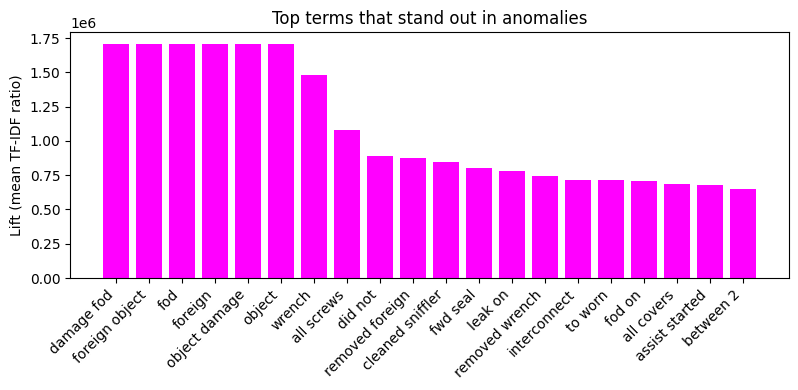

Term-lift analysis complete.


In [ ]:
# Step 17: Term-lift analysis — what terms are lifted in anomalies?

mask_top = np.zeros_like(deep_scores, dtype=bool)
mask_top[np.argsort(-deep_scores)[:TOPK]] = True
Xv = X_text_val.tocsc()
term_means_top  = np.array(Xv[mask_top].mean(axis=0)).ravel()
term_means_rest = np.array(Xv[~mask_top].mean(axis=0)).ravel() + 1e-8
lift = term_means_top / term_means_rest
terms = np.array(tfidf.get_feature_names_out())
top_idx = np.argsort(-lift)[:20]
top_terms, top_vals = terms[top_idx], lift[top_idx]
plt.figure(figsize=(8,4))
plt.bar(range(len(top_vals)), top_vals, color="magenta")
plt.xticks(range(len(top_vals)), top_terms, rotation=45, ha="right")
plt.ylabel("Lift (mean TF-IDF ratio)")
plt.title("Top terms that stand out in anomalies")
save_and_show(f"{OUT_DIR}/top_terms_lift.png")
pd.DataFrame({"term": top_terms, "lift": top_vals}).to_csv(f"{OUT_DIR}/top_terms_lift.csv", index=False)
print("Term-lift analysis complete.")

In [ ]:
# Step 18: Results summary table

metrics_table = pd.DataFrame(results).T.reset_index().rename(columns={"index":"Model"})
metrics_table.to_csv(f"{OUT_DIR}/results_table.csv", index=False)
display(metrics_table)
print("Results table saved:", f"{OUT_DIR}/results_table.csv")

,Model,AP,P@50,P@100
0,Text_OCSVM,0.331060,0.36,0.40
1,IsolationForest,0.535862,0.78,0.68
2,Hybrid,0.534074,0.78,0.69
3,DeepAutoencoder,0.351932,0.40,0.35


Results table saved: dissertation_outputs/results_table.csv


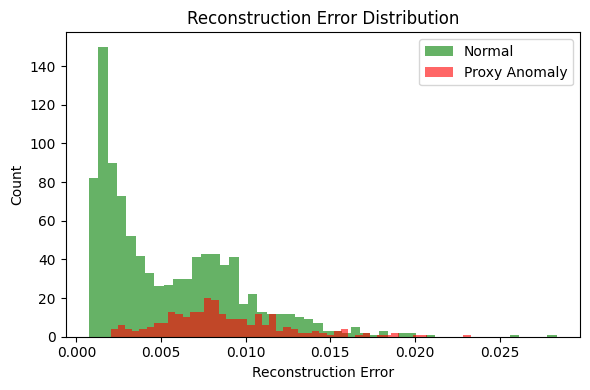

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


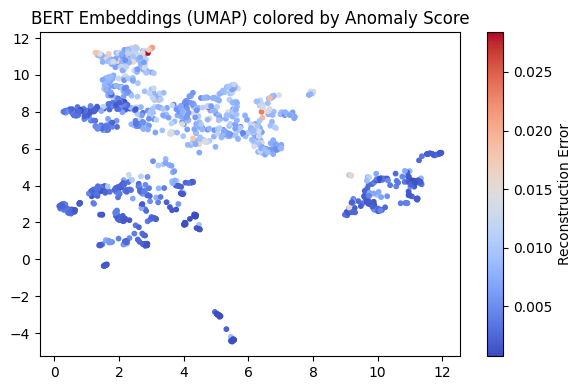

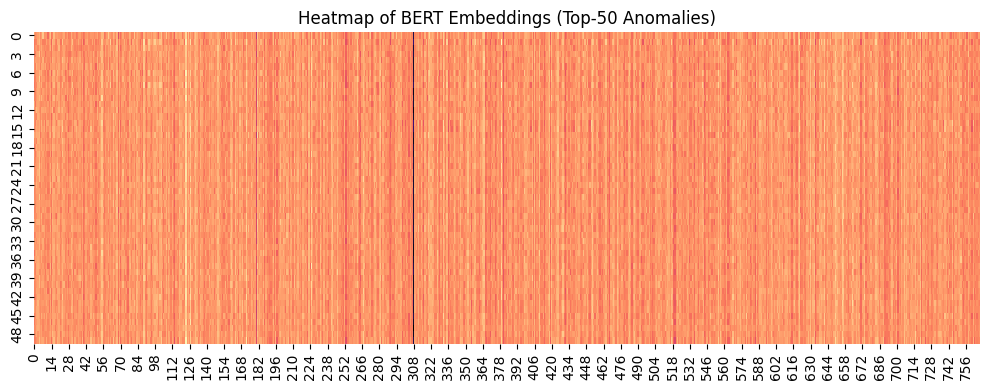

In [ ]:
# Step 19: Extra visualizations (autoencoder loss, error distribution, UMAP, heatmap)

plt.figure(figsize=(6,4))
plt.hist(deep_scores[y_val==0], bins=50, alpha=0.6, label="Normal", color="green")
plt.hist(deep_scores[y_val==1], bins=50, alpha=0.6, label="Proxy Anomaly", color="red")
plt.xlabel("Reconstruction Error"); plt.ylabel("Count")
plt.title("Reconstruction Error Distribution")
plt.legend()
save_and_show(f"{OUT_DIR}/autoencoder_error_distribution.png")

if HAS_UMAP:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
    emb2d = reducer.fit_transform(bert_val)
    plt.figure(figsize=(6,4))
    plt.scatter(emb2d[:,0], emb2d[:,1], c=deep_scores, cmap="coolwarm", s=10)
    plt.colorbar(label="Reconstruction Error")
    plt.title("BERT Embeddings (UMAP) colored by Anomaly Score")
    save_and_show(f"{OUT_DIR}/umap_autoencoder.png")

import seaborn as sns
topk_idx = np.argsort(-deep_scores)[:50]
plt.figure(figsize=(10,4))
sns.heatmap(bert_val[topk_idx], cmap="magma", cbar=False)
plt.title("Heatmap of BERT Embeddings (Top-50 Anomalies)")
save_and_show(f"{OUT_DIR}/bert_anomaly_heatmap.png")

Found 15 PNGs in 'dissertation_outputs'
— abbr_hist.png


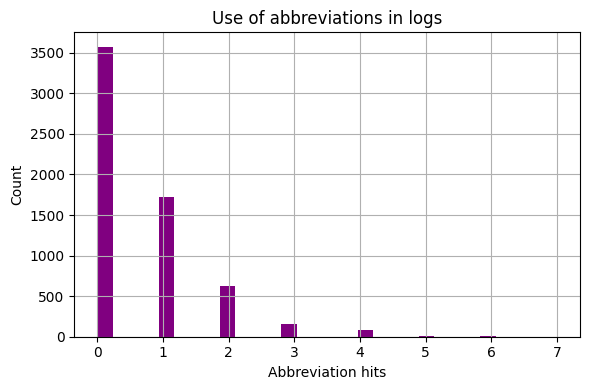

— autoencoder_error_distribution.png


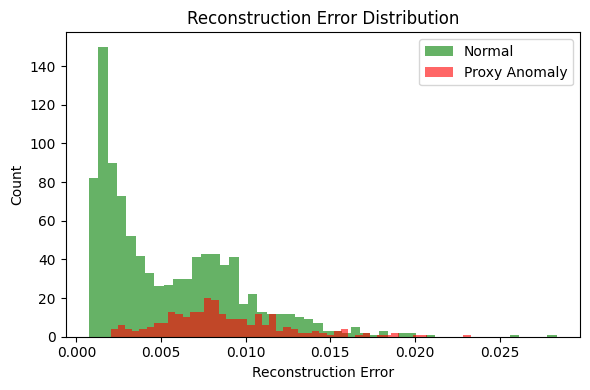

— autoencoder_loss.png


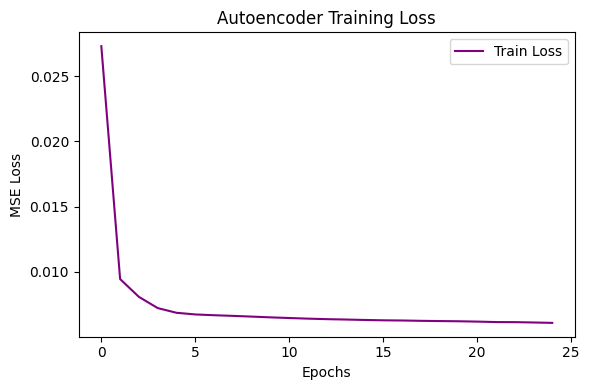

— bert_anomaly_heatmap.png


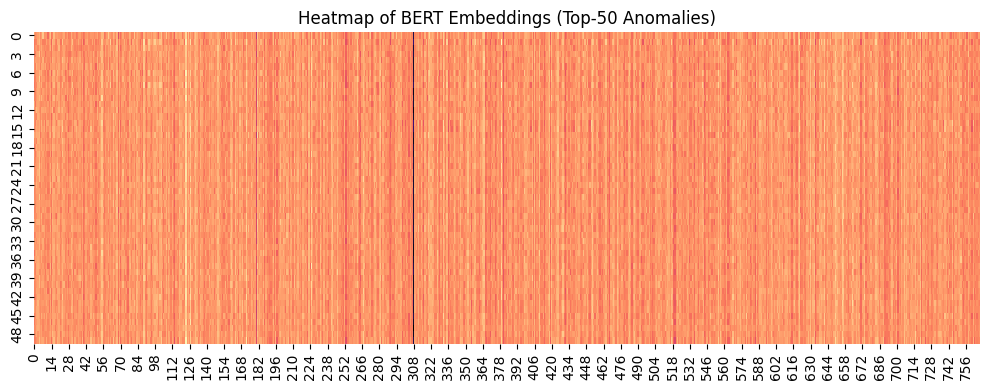

— pr_deep.png


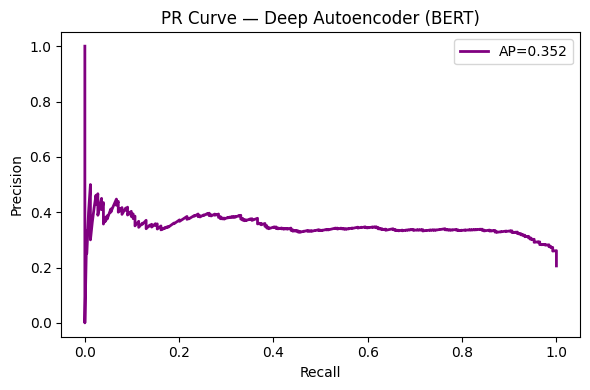

— pr_hybrid.png


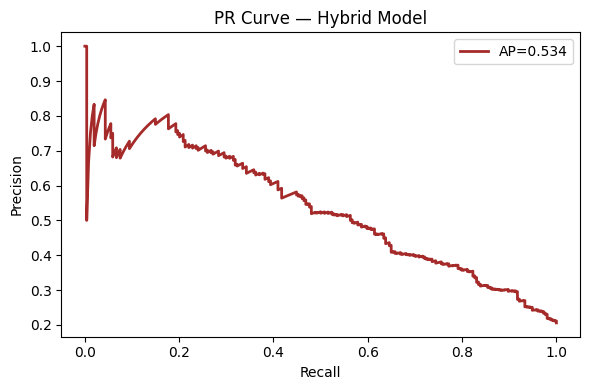

— pr_if.png


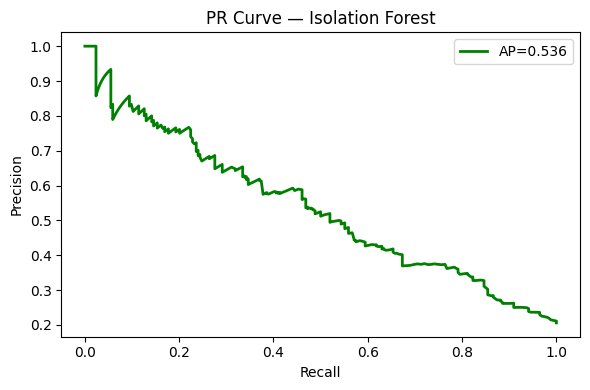

— pr_text.png


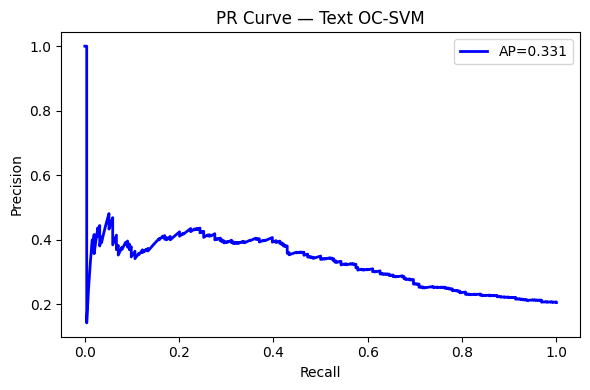

— termbank_hist.png


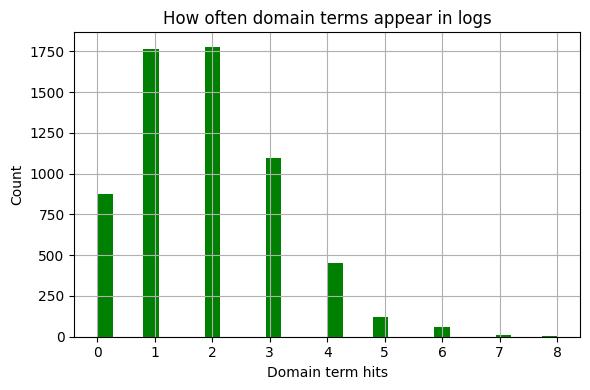

— text_len_cdf.png


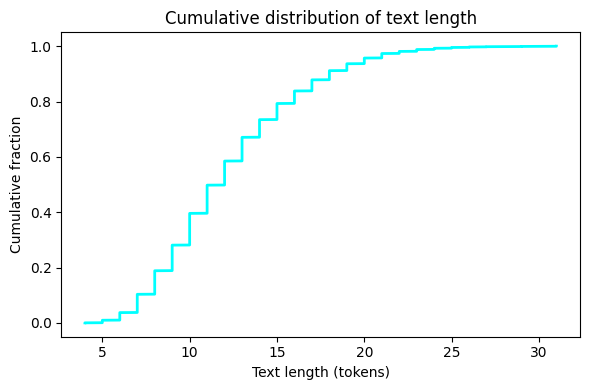

— text_len_hist.png


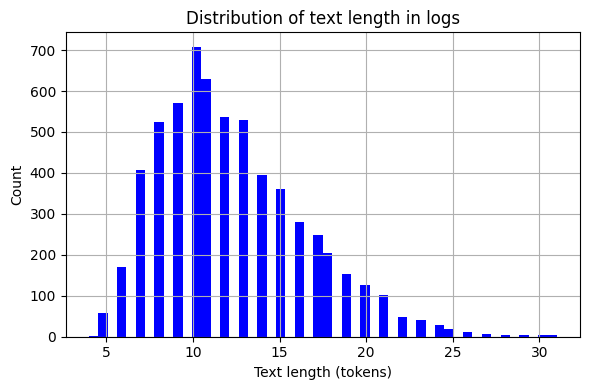

— top_bigrams.png


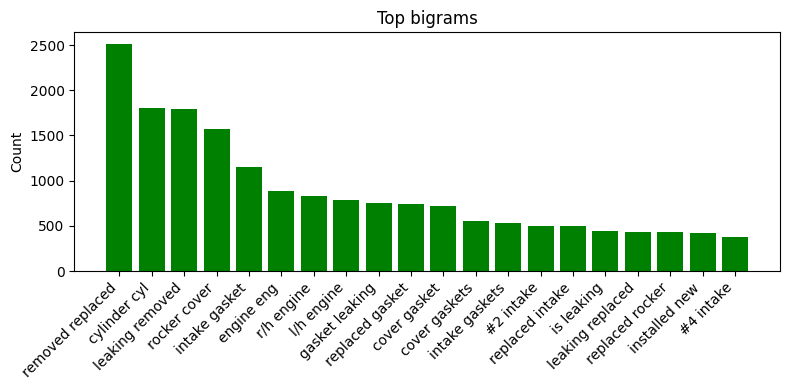

— top_terms_lift.png


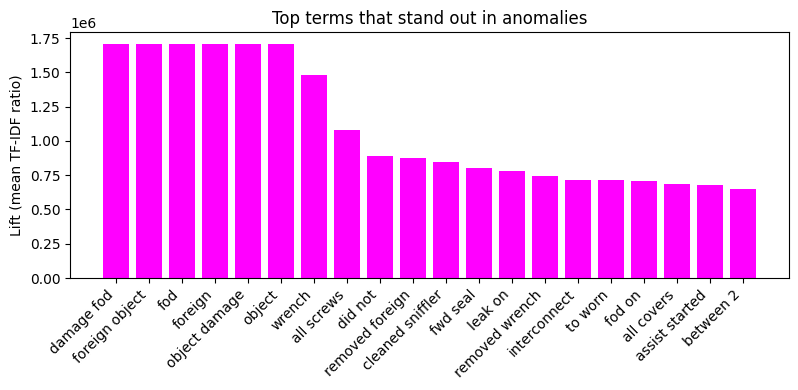

— top_unigrams.png


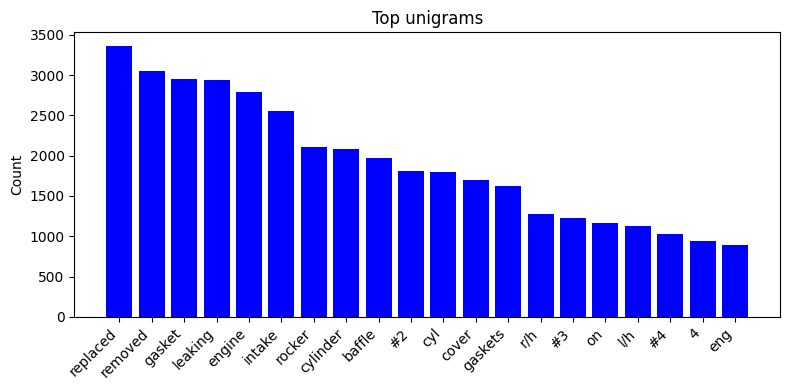

— umap_autoencoder.png


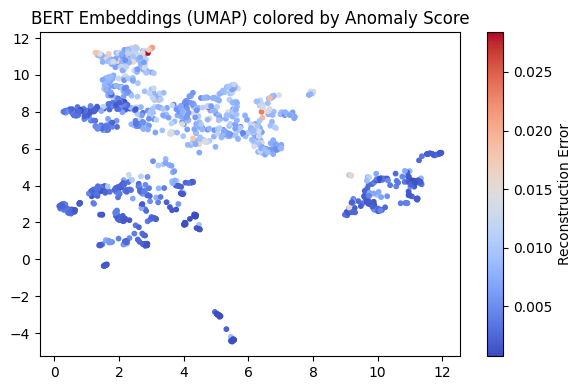

In [ ]:
# Step 20: Preview all output PNGs

def show_all_pngs(folder=OUT_DIR, max_show=30):
    pngs = [p for p in os.listdir(folder) if p.lower().endswith(".png")]
    print(f"Found {len(pngs)} PNGs in '{folder}'")
    for i, name in enumerate(sorted(pngs)):
        if i >= max_show: print(f"... {len(pngs)-max_show} more not shown"); break
        print("—", name); display(Image(filename=os.path.join(folder, name)))
show_all_pngs()